# Run SCA / PCA / dPCA / Supervised method (Gamal) on center-out reaching data

## Import packages

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
from scipy import io
import seaborn as sns

import sys

from sca.models import SCA, WeightedPCA
from sca.util import get_sample_weights,get_accuracy

sys.path.append('../dPCA-main')
from dPCA import dPCA

In [3]:
matplotlib.rc('font', size=18)

## Load Data

In [4]:
# which monkey are we working with?
monkName = 'Balboa'

In [5]:
# folder with rates
load_folder='../../datasets/'

# load data
data=io.loadmat(load_folder + monkName + '_outAndBack_redYellowConds_rawRates.mat')

# pull out the psths
# data is a C x N x T tensor 
data_array=data['data']

In [6]:
data_array.shape

(8, 124, 3003)

## Preprocess data


In [7]:
#Downsample data (using a factor of 10 here)
data_downsamp=data_array[:,:,np.arange(0,data_array.shape[2],10)]

# pull out some useful numbers
numConds,numN,trlDur = np.shape(data_downsamp)

#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_concat=data_downsamp.swapaxes(0,1).reshape([data_downsamp.shape[1],data_downsamp.shape[0]*data_downsamp.shape[2]])

#fr range
fr_range=np.ptp(data_concat,axis=1)[:,None]

# make a time mask
timeMask = np.tile(np.arange(trlDur),(1,numConds)).T.flatten()

# define the times we want to use for ssa/pca
# target on: 20
# move on:   77
# return:    200
trainTimes = np.arange(20,230)

# define a 'training mask' for convenience 
trainMask = np.in1d(timeMask,trainTimes)

In [ ]:
# Process data for SCA/PCA
#Subtract cross-condition mean
data_scm=data_downsamp-np.mean(data_downsamp,axis=0)[None,:,:]

#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_scm_concat=data_scm.swapaxes(0,1).reshape([data_downsamp.shape[1],data_downsamp.shape[0]*data_downsamp.shape[2]])

#Soft normalize (divide each neuron by its fr range + 5)
data_scm_norm=data_scm_concat/(fr_range+5)

fit_data=np.copy(data_scm_norm.T) 
# how much to weight each timestep (used by)
sample_weights=get_sample_weights(fit_data)

# Save processed neural data for matlab use in supervised method (gamal)
# io.savemat(saveDir+ monkName + '_' + 'proc_neural_data.mat'
#            , {'neuron_proc_activity': fit_data})

In [9]:
# Process data for dPCA
fit_data_weighted = (fit_data * sample_weights) #manually weight data for dPCA (CT*N)
# data is a N x C x T tensor 
data_nst_norm_w = fit_data_weighted.T.reshape([data_downsamp.shape[1],data_downsamp.shape[0], data_downsamp.shape[2]])
data_nst_norm = fit_data.T.reshape([data_downsamp.shape[1],data_downsamp.shape[0], data_downsamp.shape[2]]) 

## Fit dPCA

In [10]:
R_est = 8
trainT = np.arange(20,230)
trialT = np.arange(trlDur)
dpcaMask = np.in1d(trialT, trainT)

dpca = dPCA.dPCA(labels='st',n_components=R_est)
dpca.protect = ['t']
dpca.fit(data_nst_norm_w[:,:,dpcaMask])
dpca_latents = dpca.transform(data_nst_norm)

T = data_nst_norm.shape[2]
S = data_nst_norm.shape[1]

In [11]:
dpca_order_var=np.argsort(-np.array(dpca.explained_variance_ratio_['st']))

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

dpca_proj = dpca_latents['st'][dpca_order_var[:8]].transpose(2,1,0)
R_est = 8

dpca_cMap  = ['#0bffe0', '#0ae2c7', '#0ac6af', '#0aaa97', '#0a8d7e', '#0a7166', '#0a554e', '#0a3936']

# define some useful time points
tgt_idx=20
move_idx=77
ret_idx=200
# range for y axis
yRange = [-1.8,1.8]
fig = make_subplots(rows=R_est,cols = 1,shared_xaxes = True,vertical_spacing = 0)

for ii in range(R_est):

    for jj in range(numConds):
        latTrace = go.Scatter(y = dpca_proj[:,jj,ii], line = go.scatter.Line(color = dpca_cMap[jj],width = 1),showlegend = False)
        fig.add_trace(latTrace,row = ii+1,col=1)
        if ii == (R_est-1):
            fig.add_vline(x = tgt_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = move_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = ret_idx,row = ii+1,col = 1, line_color = 'black')

            #
    # add a vertical line for scale
    scaleLine = go.Scatter(x = [-5, -5],y = [-0.4,0.4],showlegend = False,mode = 'lines',
                            line = go.scatter.Line(color = 'black',width = 3))
    fig.add_trace(scaleLine,row = ii+1,col = 1)


fig.update_layout(height = 1000,width =500,title = 'dPCA ' + monkName,title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False,range = yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,50],ticktext = ['0','500'],visible = True,row = R_est,col = 1)


# save
# fig.write_image(figDir + monkName + 'dpca_' + str(R_est) + 'dims.pdf')
fig.show()


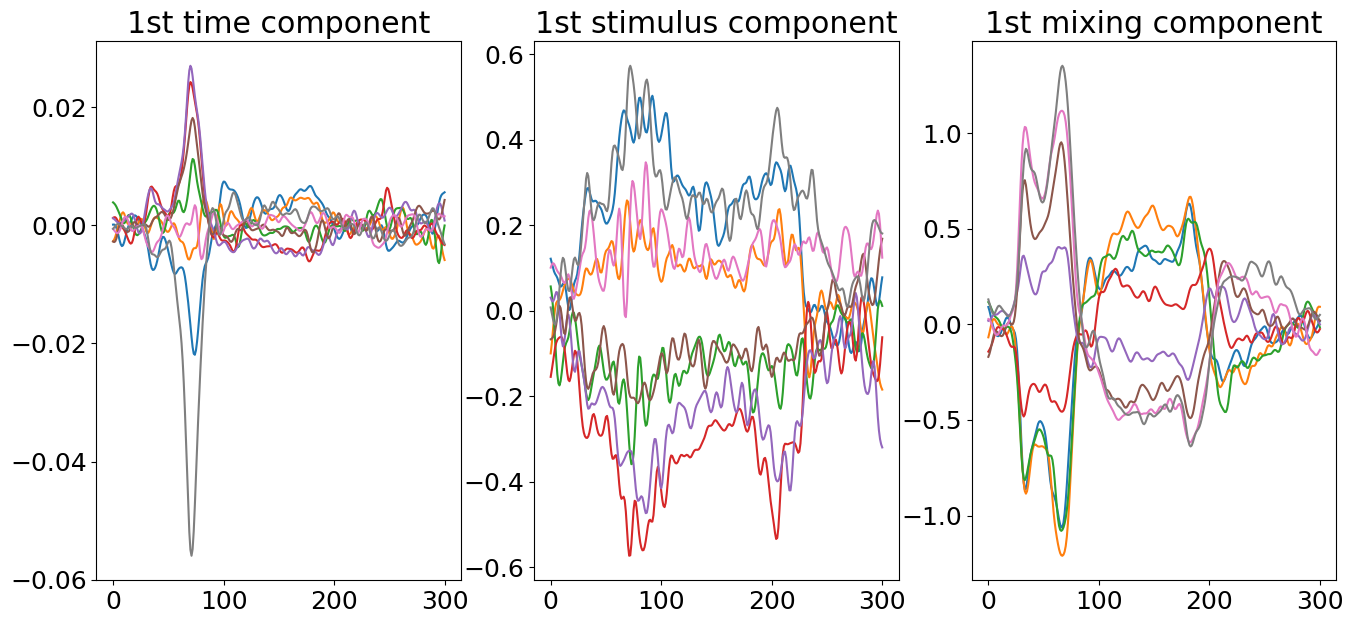

In [13]:
time = np.arange(T)

plt.figure(figsize=(16,7))
plt.subplot(131)

for s in range(S):
    plt.plot(time,dpca_latents['t'][0,s])

plt.title('1st time component')
    
plt.subplot(132)

for s in range(S):
    plt.plot(time,dpca_latents['s'][1,s])
    
plt.title('1st stimulus component')
    
plt.subplot(133)

for s in range(S):
    plt.plot(time,dpca_latents['st'][0,s])
    
plt.title('1st mixing component')
plt.show()

## Fit SCA and PCA

In [14]:
fit_data=np.copy(data_scm_norm.T) 
# how much to weight each timestep (used by)
sample_weights=get_sample_weights(fit_data)

# number of dimensions to find
R_est= 8

Using lam_sparse=  0.02621325763435081
Using lam_orthog=  146.98663583045976
Using device cpu
505.6178
3140.1099


100%|██████████| 3000/3000 [00:10<00:00, 278.78it/s]


Text(0.5, 1.0, 'Loss over training')

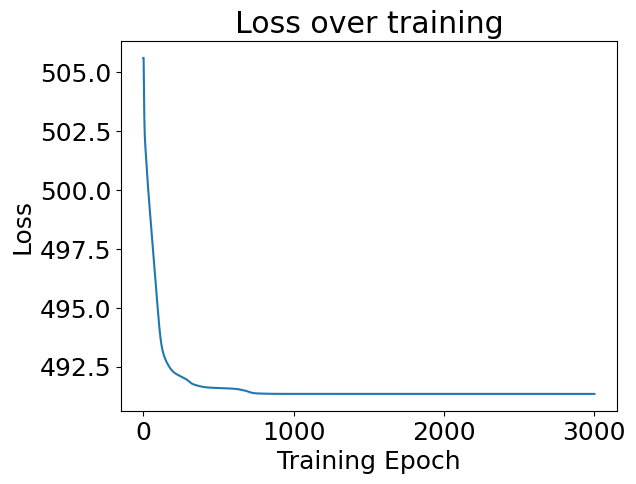

In [15]:
sca = SCA(n_components=R_est,orth=False)
sca.fit(fit_data[trainMask,:],sample_weight=sample_weights[trainMask])
sca_latent = sca.transform(fit_data)

losses = sca.losses
#Plot the loss over all iterations
plt.figure()
plt.plot(losses)
plt.xlabel('Training Epoch')
plt.ylabel('Loss')
plt.title('Loss over training')

In [16]:
#Run weighted PCA for comparison

wpca = WeightedPCA(n_components=R_est)
wpca.fit(fit_data[trainMask,:],sample_weight=sample_weights[trainMask])
wpca_latent = wpca.transform(fit_data)  

Text(0.5, 1.0, 'PCA LowD Projections')

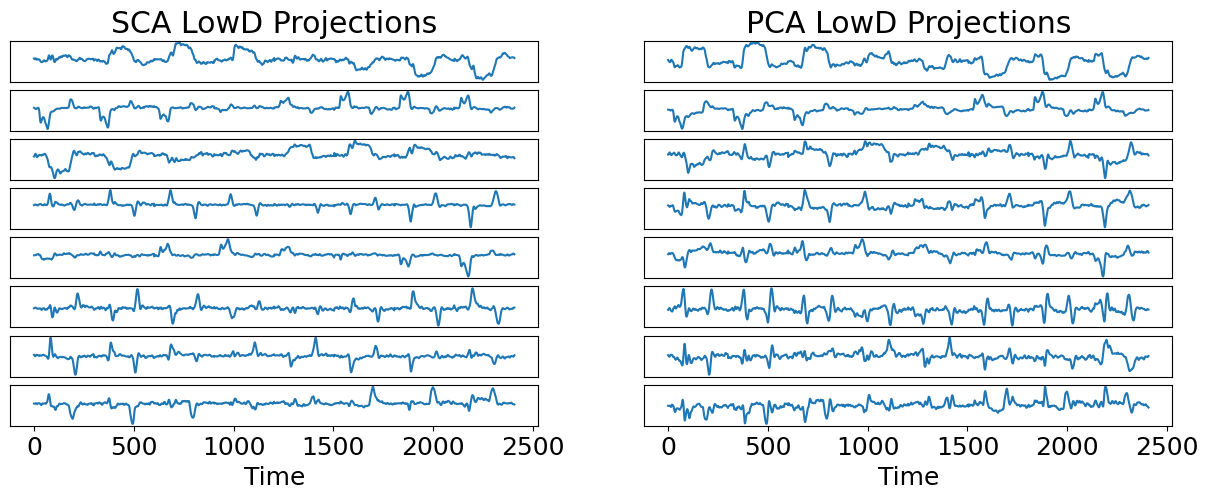

In [17]:
plt.figure(figsize=(15,5))
for i in range(R_est):
    
  
    # Plot SSA results
    plt.subplot(R_est,2,2*i+1)
    plt.plot(sca_latent[:,i])
    
    plt.yticks([])    
    if i<R_est-1:
        plt.xticks([])
    else:
        plt.xlabel('Time')

    # Plot PCA results
    plt.subplot(R_est,2,2*i+2)
    plt.plot(wpca_latent[:,i])
    
    plt.yticks([])
    if i<R_est-1:
        plt.xticks([])
    else:
        plt.xlabel('Time')        


plt.subplot(R_est,2,1)
plt.title('SCA LowD Projections')

plt.subplot(R_est,2,2)
plt.title('PCA LowD Projections')


In [18]:
# fraction of colormap to use
colorIdx = np.arange(0.55,1,0.4/8)

# define ssa colors
sca_cMap = sns.cubehelix_palette(start = 0.1,rot = 0.6,dark = 0.15, light = 0.8,as_cmap = True,gamma = 1.1)
sca_cMap = sca_cMap(colorIdx)

# define pca colors
pca_cMap = sns.cubehelix_palette(start = 0.1,rot = 0.6,dark = 0.15, light = 0.8,as_cmap = True,gamma = 0.7,hue = 0.3)
pca_cMap = pca_cMap(colorIdx)


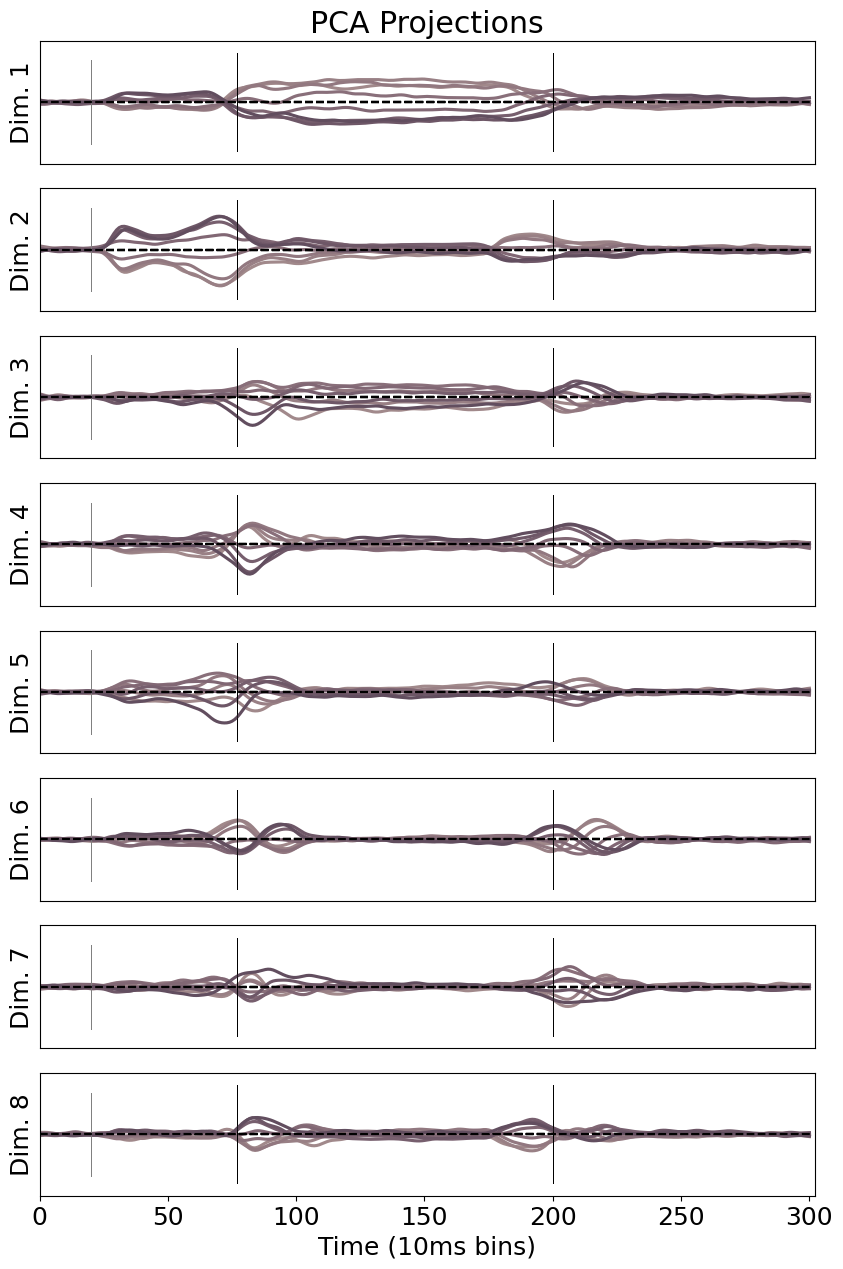

In [ ]:
#Get indices of each trial
T=data_downsamp.shape[2] #Length of time per condition
trs=np.arange(0,8)
t_idxs=[np.arange(T*tr,T*(tr+1)) for tr in trs]

# define some useful time points
tgt_idx=20
move_idx=77
ret_idx=200

# change color of axis labels so we can see them in the pdf
plt.rcParams['text.color'] = 'k'
plt.rcParams['xtick.color'] = 'k'
plt.rcParams['ytick.color'] = 'k'
plt.rcParams['axes.labelcolor'] = 'k'


fig,ax=plt.subplots(R_est,1,figsize=(10,15))
for i in range(R_est):
    for j in range(len(trs)):

        ax[i].plot(wpca_latent[:,i][t_idxs[j]] - np.mean(wpca_latent[:,i]),linewidth=2.25,color=pca_cMap[j,:])
        
        ax[i].plot([tgt_idx,tgt_idx],[-1.7,1.7],'gray',linewidth=.5)
        ax[i].plot([move_idx,move_idx],[-2,2],'k',linewidth=.5)
        ax[i].plot([ret_idx,ret_idx],[-2,2],'k',linewidth=.5)

        ax[i].set_xlim([0,T+1])
        ax[i].set_ylim([-2.5, 2.5])
        ax[i].plot([0,T],[0,0],'k--')
        if i<R_est-1:
            ax[i].set_xticks([])
        else:
            ax[i].set_xlabel('Time (10ms bins)')
            
        ax[i].set_yticks([])
        ax[i].set_ylabel('Dim. '+str(i+1))

    ax[0].set_title('PCA Projections')

# # save figure

# save directory
# figDir = '..'
# plt.savefig(figDir + monkName + '_pcaProj_original_dim' + str(R_est) + '.pdf',dpi = 'figure')

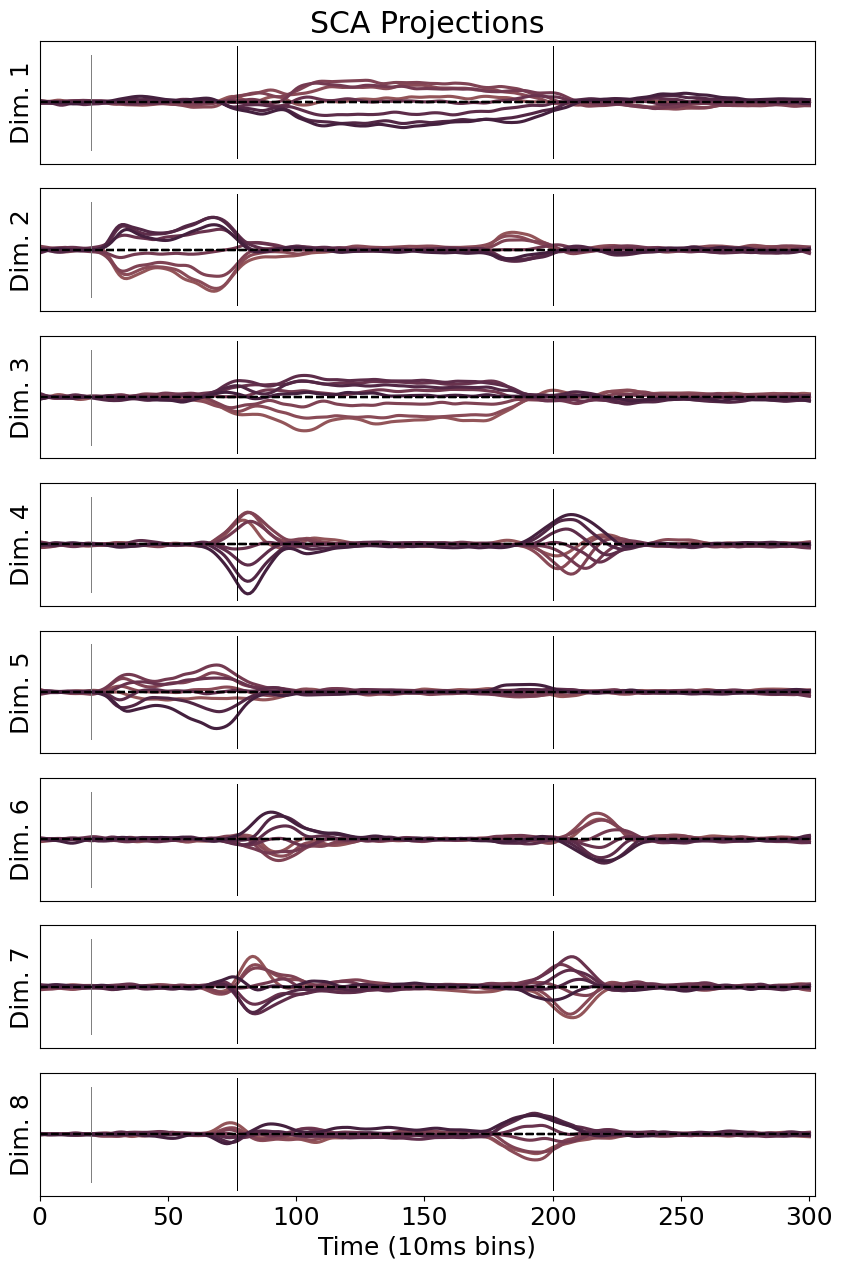

In [ ]:
#Get indices of each trial
T=data_downsamp.shape[2] #Length of time per condition
trs=np.arange(0,8)
t_idxs=[np.arange(T*tr,T*(tr+1)) for tr in trs]


fig,ax=plt.subplots(R_est,1,figsize=(10,15))
for i in range(R_est):
    for j in range(len(trs)):

        ax[i].plot(sca_latent[:,i][t_idxs[j]] - np.mean(sca_latent[:,i]),linewidth=2.25,color=sca_cMap[j,:])
        
        ax[i].plot([tgt_idx,tgt_idx],[-1.7,1.7],'gray',linewidth=.5)
        ax[i].plot([move_idx,move_idx],[-2,2],'k',linewidth=.5)
        ax[i].plot([ret_idx,ret_idx],[-2,2],'k',linewidth=.5)
        ax[i].plot([0,T],[0,0],'k--')

        ax[i].set_xlim([0,T+1])
        ax[i].set_ylim([-2.5, 2.5])

        if i<R_est-1:
            ax[i].set_xticks([])
        else:
            ax[i].set_xlabel('Time (10ms bins)')
            
        ax[i].set_yticks([])
        ax[i].set_ylabel('Dim. '+str(i+1))

    ax[0].set_title('SCA Projections')

# save
# plt.savefig(figDir + monkName + '_scaProj_original_dim' + str(R_est) + '.pdf',dpi = 'figure')

## Plot supervised method

### Properly supervised

In [ ]:
# Load Gamal results 
gamal_data=io.loadmat(load_folder + monkName + '_gamalLoadings.mat') # Saved from matlab script

In [25]:
# defind prep, move, and post projections
gamal_PrepProj = gamal_data['prepProj_list'][:,:,None]
gamal_MoveProj = gamal_data['moveProj_list'][:,:,None]
gamal_PostProj = gamal_data['postProj_list'][:,:,None]
print(gamal_PrepProj.shape)

(2408, 12, 1)


In [27]:
gProj = np.concatenate((gamal_PrepProj, gamal_PostProj, gamal_MoveProj),axis = -1)
print(gProj.shape)
gProj_reshaped = np.hstack([gProj[:,:3,0], gProj[:,:2,1], gProj[:,:3,2]])
gProj_reshaped.shape
gProj_plot = np.reshape(gProj_reshaped,(trlDur,8,R_est),order='F')
gProj_plot.shape

(2408, 12, 3)


(301, 8, 8)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


g_cMap  = ['#00d01e', '#00ba22', '#00a426', '#008e2a', '#00782e', '#006232', '#004c36', '#00363a']

# define some useful time points
tgt_idx=20
move_idx=77
ret_idx=200
# range for y axis
yRange = [-1.8,1.8]
fig = make_subplots(rows=R_est,cols = 1,shared_xaxes = True,vertical_spacing = 0)

for ii in range(R_est):

    for jj in range(numConds):
        latTrace = go.Scatter(y = gProj_plot[:,jj,ii], line = go.scatter.Line(color = g_cMap[jj],width = 1),showlegend = False)
        fig.add_trace(latTrace,row = ii+1,col=1)
        if ii == (R_est-1):
            fig.add_vline(x = tgt_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = move_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = ret_idx,row = ii+1,col = 1, line_color = 'black')

            #
    # add a vertical line for scale
    scaleLine = go.Scatter(x = [-5,-5],y = [-0.4,0.4],showlegend = False,mode = 'lines',
                            line = go.scatter.Line(color = 'black',width = 3))
    fig.add_trace(scaleLine,row = ii+1,col = 1)


fig.update_layout(height = 1000,width =500,title = 'Properly supervised ' + monkName,title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False,range = yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,50],ticktext = ['0','500'],visible = True,row = R_est,col = 1)


# save
# fig.write_image(figDir + monkName + 'Gamal_' + str(R_est) + 'dims.pdf')
fig.show()


### Naively supervised

In [ ]:
mixed_gamal_data=io.loadmat(load_folder + monkName + '_MIX2_gamalLoadings.mat') # Saved from matlab script

In [31]:
# defind prep, move, and post projections
mix_gamal_PrepProj = mixed_gamal_data['prepProj_list'][:,:,None]
mix_gamal_MixProj = mixed_gamal_data['mixProj_list'][:,:,None]
print(mix_gamal_MixProj.shape)

(2408, 12, 1)


In [37]:
mix_gProj = np.concatenate((mix_gamal_PrepProj,mix_gamal_MixProj),axis = -1)
print(mix_gProj.shape)
mix_gProj_reshaped = np.hstack([mix_gProj[:,:4,0], mix_gProj[:,:4,1]])
mix_gProj_reshaped.shape
mix_gProj_plot = np.reshape(mix_gProj_reshaped,(trlDur,8,R_est),order='F')
print(mix_gProj_plot.shape)
mix_g_cMap  = ['#e8a048', '#d48b3f', '#c07737', '#ac632e', '#984e26', '#843a1d', '#702615', '#5c120d']

(2408, 12, 2)
(301, 8, 8)


In [ ]:
yRange = [-1.8,1.8]
fig = make_subplots(rows=R_est,cols = 1,shared_xaxes = True,vertical_spacing = 0)

for ii in range(R_est):

    for jj in range(numConds):
        latTrace = go.Scatter(y = mix_gProj_plot[:,jj,ii], line = go.scatter.Line(color = mix_g_cMap[jj],width = 1),showlegend = False)
        fig.add_trace(latTrace,row = ii+1,col=1)
        if ii == (R_est-1):
            fig.add_vline(x = tgt_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = move_idx,row = ii+1,col = 1, line_color = 'black')
            fig.add_vline(x = ret_idx,row = ii+1,col = 1, line_color = 'black')

    # add a vertical line for scale
    scaleLine = go.Scatter(x = [-5,-5],y = [-0.4,0.4],showlegend = False,mode = 'lines',
                            line = go.scatter.Line(color = 'black',width = 3))
    fig.add_trace(scaleLine,row = ii+1,col = 1)


fig.update_layout(height = 1000,width =500,title = 'Naively supervised ' + monkName,title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False,range = yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,50],ticktext = ['0','500'],visible = True,row = R_est,col = 1)


# save
# fig.write_image(figDir + monkName + 'MIX_Gamal_' + str(R_est) + 'dims.pdf')
fig.show()


# Bootstrap comparison

### Run bootstrap for SCA/PCA

In [60]:
pca_original_latent = np.copy(wpca_latent)
sca_original_latent = np.copy(sca_latent)

In [ ]:
from scipy.stats import pearsonr
data_array_copy = np.copy(data_array)
def bootstraps(n_boots):
    dataL,numN = fit_data.shape
    sca_latents = np.zeros((dataL,R_est,n_boots))
    pca_latents = np.zeros((dataL,R_est,n_boots))
    neuron_samps = np.zeros((dataL,numN,n_boots))
    sca_r = np.zeros((R_est,n_boots))
    pca_r = np.zeros((R_est,n_boots))
    neuron_index = np.zeros((numN,n_boots))

    for n in range(n_boots):
        # draw 'numN' neurons with replacement
        nIdx = np.random.choice(numN,numN)      
        
        #save sampled neuron indices
        neuron_index[:,n] = nIdx
        
        #save sampled neuron pre-proceesed activity
        X_samp = fit_data[:,nIdx]
        neuron_samps[:,:,n] = X_samp
        
        # calculate our sample weights
        sWeights = get_sample_weights(X_samp)

        # run weighted pca
        wpca = WeightedPCA(n_components=R_est)
        wpca.fit(X_samp[trainMask,:],sample_weight=sWeights[trainMask])
        pca_lat = wpca.transform(X_samp)

        #save pca rscore and latents (check consistency with original latents using all data)
        pca_r_list = np.zeros((R_est,1))
        for i in range(R_est):
            a = np.array([abs(pearsonr(pca_lat[:,i], pca_original_latent[:,j])[0]) for j in range(R_est)])
            pca_r_list[i] = a.max()
        pca_r[:,n] = pca_r_list.ravel()
        pca_latents[:,:,n] = pca_lat
        
        # run sca
        sca = SCA(n_components=R_est,orth=False)
        sca.fit(X_samp[trainMask,:],sample_weight=sWeights[trainMask])
        sca_lat = sca.transform(X_samp)

        #save sca rscore and latents
        sca_r_list = np.zeros((R_est,1))
        for i in range(R_est):
            a = np.array([abs(pearsonr(sca_lat[:,i], sca_original_latent[:,j])[0]) for j in range(R_est)])
            sca_r_list[i] = a.max()
        sca_r[:,n] = sca_r_list.ravel()
        sca_latents[:,:,n] = sca_lat
   
    #save bootstraping results    
    saveDir='../datasets/'
    io.savemat(saveDir+ monkName + '_' + 'bootstraps'+ '_' + str(n+1) + '_dim' + str(R_est) + '.mat'
           , {"bs_sca_latents": sca_latents, "bs_pca_latents": pca_latents
           , "bs_neuron_proc_activity": neuron_samps, "sca_absR": sca_r, "pca_absR": pca_r,
             "original_data": data_array_copy, "bs_neuron_index": neuron_index})
    
    return pca_r, sca_r

In [ ]:
#run bootstraps, get arrays of absolute Pearson's R's
numBoots = 100
pca_r, sca_r = bootstraps(numBoots)

### Run bootstrap for dPCA

In [ ]:
data=io.loadmat(load_folder + monkName + '_' + 'bootstraps_100_scapca.mat')
neuron_samps = data['bs_neuron_proc_activity'] #Using same data as SCA/PCA for fair comparison

In [ ]:
R_est = 8
dataL,numN = fit_data.shape
dpca_latents = np.zeros((dataL,R_est,100))
dpca_r = np.zeros((R_est,100))

for n in range(100):

    X_samp = neuron_samps[:,:,n]
    sWeights = get_sample_weights(X_samp)

    X_samp_weighted = (X_samp * sWeights)
    d_norm_w = X_samp_weighted.T.reshape([data_downsamp.shape[1],data_downsamp.shape[0], data_downsamp.shape[2]]) # data is a N x C x T tensor 
    d_norm = X_samp.T.reshape([data_downsamp.shape[1],data_downsamp.shape[0], data_downsamp.shape[2]]) # data is a N x C x T tensor 

    trainT = np.arange(20,230)
    trialT = np.arange(trlDur)
    dpcaMask = np.in1d(trialT, trainT)

    dpca = dPCA.dPCA(labels='st',n_components=R_est)
    dpca.protect = ['t']
    dpca.fit(d_norm_w[:,:,dpcaMask])
    dpca_lat_dict = dpca.transform(d_norm)
    dpca_lat = dpca_lat_dict['st'].transpose(2,1,0)
    dpca_lat = dpca_lat.reshape((dpca_lat.shape[0]*dpca_lat.shape[1],R_est),order='F')
    dpca_latents[:,:,n] = dpca_lat
    
#save bootstraping results  
saveDir='../datasets/'
io.savemat(saveDir+ monkName + '_' + 'bootstraps'+ '_' + str(n+1) + '_dPCALoadings.mat', {"bs_dpca_latents": dpca_latents})

## load and plot

In [45]:
# Load Gamal results bootstrapping results (Saved from Matlab script)
gamal_data=io.loadmat(load_folder + monkName + '_bootstraps_100_gamalLoadings.mat')
# defind prep, move, and post projections
gamal_PrepProj = gamal_data['prepProj_list'][:,:,:,None]
gamal_MoveProj = gamal_data['moveProj_list'][:,:,:,None]
gamal_PostProj = gamal_data['postProj_list'][:,:,:,None]
print(gamal_PrepProj.shape)

(2408, 12, 100, 1)


In [46]:
#Load mixed Gamal bootstrapping results (Saved from Matlab script)
boot_data=io.loadmat(load_folder + monkName + '_bootstraps_100_MIX2_gamalLoadings.mat')
print(boot_data.keys())
mix_gamal_latents = np.concatenate([boot_data['mixProj_list'][:,:4,:],boot_data['prepProj_list'][:,:4,:]],axis=1)
print(mix_gamal_latents.shape)

dict_keys(['__header__', '__version__', '__globals__', 'mixDims_list', 'mixProj_list', 'mixWindow', 'prepDims_list', 'prepProj_list', 'prepWindow'])
(2408, 8, 100)


In [47]:
#Load PCA and SCA bootstrapping results
boot_data=io.loadmat(load_folder + monkName + '_bootstraps_100_scapca.mat')
print(boot_data.keys())
sca_latents = boot_data['bs_sca_latents']
pca_latents = boot_data['bs_pca_latents']
print(pca_latents.shape)

dict_keys(['__header__', '__version__', '__globals__', 'bs_sca_latents', 'bs_pca_latents', 'bs_neuron_proc_activity', 'sca_absR', 'pca_absR', 'original_data', 'bs_neuron_index'])
(2408, 8, 100)


In [48]:
#Load dPCA bootstrapping results
boot_data=io.loadmat(load_folder + monkName + '_bootstraps_100_dPCALoadings.mat')
print(boot_data.keys())
dpca_latents = boot_data['bs_dpca_latents']
print(dpca_latents.shape)

dict_keys(['__header__', '__version__', '__globals__', 'bs_dpca_latents'])
(2408, 8, 100)


In [49]:
## IND BEHAV
R_est = 8

# number of bootstraps
numBoots = gamal_PrepProj.shape[2]

# initialize vector to hold R2
# each -1 dimenision corresponds to the reconstruction R2 from the prep, move, or posture projections
allR2_pca = np.zeros((numBoots,R_est,3))
allR2_sca = np.zeros((numBoots,R_est,3))
allR2_mgamal = np.zeros((numBoots,R_est,3))
allR2_dpca = np.zeros((numBoots,R_est,3))

# cycle through bootstrap repetitions
for n in range(numBoots):
    gProj = np.concatenate((gamal_PrepProj[:,:,n],gamal_MoveProj[:,:,n],gamal_PostProj[:,:,n]),axis = -1)

    # get B (regression weights) from prep, move, and posture projections
    for e in np.arange(3):

        # make life a bit easier and just pull out the gamal projections we want
        X = gProj[:,:,e]        
        # pull out PCA bootstrap latents
        Y = pca_latents[:,:,n]
        # regress
        B = np.linalg.inv(X.T@X) @ X.T @ Y
        # reconstruct Y 
        Y_hat = X @ B    
        # calculate R2
        ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
        ss_res = np.sum((Y - Y_hat)**2,axis = 0)
        allR2_pca[n,:,e] = 1 - (ss_res/ss_tot)
    

        # pull out dPCA bootstrap latents
        Y = dpca_latents[:,:,n]
        # regress
        B = np.linalg.inv(X.T@X) @ X.T @ Y
        # reconstruct Y 
        Y_hat = X @ B
        # calculate R2
        ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
        ss_res = np.sum((Y - Y_hat)**2,axis = 0)
        allR2_dpca[n,:,e] = 1 - (ss_res/ss_tot)

    
        # pull out Mixed Gamal bootstrap latents
        Y = mix_gamal_latents[:,:,n]
        # regress
        B = np.linalg.inv(X.T@X) @ X.T @ Y
        # reconstruct Y 
        Y_hat = X @ B
        # calculate R2
        ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
        ss_res = np.sum((Y - Y_hat)**2,axis = 0)
        allR2_mgamal[n,:,e] = 1 - (ss_res/ss_tot)        

    
        # pull out SCA bootstrap latents
        Y = sca_latents[:,:,n]
        # regress
        B = np.linalg.inv(X.T@X) @ X.T @ Y
        # reconstruct Y 
        Y_hat = X @ B
        # calculate R2
        ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
        ss_res = np.sum((Y - Y_hat)**2,axis = 0)
        allR2_sca[n,:,e] = 1 - (ss_res/ss_tot)

# take max R2 for each dimension 
maxR2_mgamal = np.max(allR2_mgamal,axis = 2)
maxR2_sca = np.max(allR2_sca,axis = 2)
maxR2_pca = np.max(allR2_pca,axis = 2)
maxR2_dpca = np.max(allR2_dpca,axis = 2)

In [50]:
## IND BEHAV (baseline: random rotations of PCA latents)
R_est = 8

# number of bootstraps
numBoots = gamal_PrepProj.shape[2]

# initialize vector to hold R2
# each -1 dimenision corresponds to the reconstruction R2 from the prep, move, or posture projections
allR2_pca_rot = np.zeros((numBoots,R_est,3))

# cycle through bootstrap repetitions
for n in range(numBoots):
    gProj = np.concatenate((gamal_PrepProj[:,:,n],gamal_MoveProj[:,:,n],gamal_PostProj[:,:,n]),axis = -1)

    # pull out PCA bootstrap latents
    Y = pca_latents[:,:,n]
    Q, _ = np.linalg.qr(np.random.randn(R_est, R_est))
    Y_null = Y @ Q
    Y = Y_null

    # get B (regression weights) from prep, move, and posture projections
    for e in np.arange(3):

        # make life a bit easier and just pull out the gamal projections we want
        X = gProj[:,:,e]

        # regress
        B = np.linalg.inv(X.T@X) @ X.T @ Y

        # reconstruct Y 
        Y_hat = X @ B
    
        # calculate R2
        ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
        ss_res = np.sum((Y - Y_hat)**2,axis = 0)
        allR2_pca_rot[n,:,e] = 1 - (ss_res/ss_tot)
    
# take max R2 for each dimension 
maxR2_pca_rotate = np.max(allR2_pca_rot,axis = 2)

In [51]:
# ALL BEHAV

# number of bootstraps
numBoots = gamal_PrepProj.shape[2]

# initialize vector to hold R2
allR2_pca = np.zeros((numBoots,R_est))
allR2_mgamal = np.zeros((numBoots,R_est))
allR2_sca = np.zeros((numBoots,R_est))
allR2_dpca = np.zeros((numBoots,R_est))

# cycle through bootstrap repetitions
for n in range(numBoots):
    gProj = np.concatenate((gamal_PrepProj[:,:,n],gamal_MoveProj[:,:,n],gamal_PostProj[:,:,n]),axis = -1)
    gProj = gProj.reshape(gProj.shape[0],-1)

    # pull out PCA bootstrap latents
    Y = pca_latents[:,:,n]
    # pull out all gamal projections
    X = gProj
    # regress
    B = np.linalg.inv(X.T@X) @ X.T @ Y
    # reconstruct Y 
    Y_hat = X @ B
    # calculate R2
    ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
    ss_res = np.sum((Y - Y_hat)**2,axis = 0)
    allR2_pca[n,:] = 1 - (ss_res/ss_tot)

    # pull out dPCA bootstrap latents
    Y = dpca_latents[:,:,n]
    # pull out all gamal projections
    X = gProj
    # regress
    B = np.linalg.inv(X.T@X) @ X.T @ Y
    # reconstruct Y 
    Y_hat = X @ B
    # calculate R2
    ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
    ss_res = np.sum((Y - Y_hat)**2,axis = 0)
    allR2_dpca[n,:] = 1 - (ss_res/ss_tot)

    # pull out mixed gamal bootstrap latents
    Y = mix_gamal_latents[:,:,n]
    # pull out all gamal projections
    X = gProj
    # regress
    B = np.linalg.inv(X.T@X) @ X.T @ Y
    # reconstruct Y 
    Y_hat = X @ B
    # calculate R2
    ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
    ss_res = np.sum((Y - Y_hat)**2,axis = 0)
    allR2_mgamal[n,:] = 1 - (ss_res/ss_tot)

    # pull out SCA bootstrap latents
    Y = sca_latents[:,:,n]
    # pull out all gamal projections
    X = gProj
    # regress
    B = np.linalg.inv(X.T@X) @ X.T @ Y
    # reconstruct Y 
    Y_hat = X @ B
    # calculate R2
    ss_tot = np.sum((Y - np.mean(Y,axis = 0))**2, axis = 0)
    ss_res = np.sum((Y - Y_hat)**2,axis = 0)
    allR2_sca[n,:] = 1 - (ss_res/ss_tot)

In [52]:
# fraction of colormap to use
colorIdx = np.arange(0.55,1,0.4/8)

# define ssa colors
sca_cMap = sns.cubehelix_palette(start = 0.1,rot = 0.6,dark = 0.15, light = 0.8,as_cmap = True,gamma = 1.1)
sca_cMap = sca_cMap(colorIdx)

# define pca colors
pca_cMap = sns.cubehelix_palette(start = 0.1,rot = 0.6,dark = 0.15, light = 0.8,as_cmap = True,gamma = 0.7,hue = 0.3)
pca_cMap = pca_cMap(colorIdx)

mgamal_cMap = ['#e8a048', '#d48b3f', '#c07737', '#ac632e', '#984e26', '#843a1d', '#702615', '#5c120d']
dpca_cMap  = ['#0bffe0', '#0ae2c7', '#0ac6af', '#0aaa97', '#0a8d7e', '#0a7166', '#0a554e', '#0a3936']



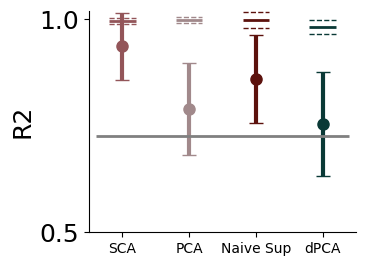

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Adjust axis label colors for better PDF visibility
plt.rcParams['text.color'] = 'k'
plt.rcParams['xtick.color'] = 'k'
plt.rcParams['ytick.color'] = 'k'
plt.rcParams['axes.labelcolor'] = 'k'

# General style adjustments
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True

# Define cap size and style
capsize = 5
capstyle = {'linestyle': ':'}

# Create figure
fig, ax = plt.subplots(figsize=(4, 3))

# Add horizontal lines for "all_xxx_recon" mean ± error bars
all_scaR2_recon = np.reshape(allR2_sca, [-1, 1], order='F')
mean_all_sca = np.mean(all_scaR2_recon)
std_all_sca = np.std(all_scaR2_recon)
ax.hlines(mean_all_sca, 0.8, 1.2, color=sca_cMap[0],  lw=2)
ax.hlines([mean_all_sca - std_all_sca, mean_all_sca + std_all_sca], 0.8, 1.2, 
          color=sca_cMap[0], linestyle='--', lw=1)

all_pcaR2_recon = np.reshape(allR2_pca, [-1, 1], order='F')
mean_all_pca = np.mean(all_pcaR2_recon)
std_all_pca = np.std(all_pcaR2_recon)
ax.hlines(mean_all_pca, 1.8, 2.2, color=pca_cMap[0], lw=2)
ax.hlines([mean_all_pca - std_all_pca, mean_all_pca + std_all_pca], 1.8, 2.2, 
          color=pca_cMap[0], linestyle='--', lw=1)

all_mgamalR2_recon = np.reshape(allR2_mgamal, [-1, 1], order='F')
mean_all_mgamal = np.mean(all_mgamalR2_recon)
std_all_mgamal = np.std(all_mgamalR2_recon)
ax.hlines(mean_all_mgamal, 2.8, 3.2, color=mgamal_cMap[-1],  lw=2)
ax.hlines([mean_all_mgamal - std_all_mgamal, mean_all_mgamal + std_all_mgamal], 2.8, 3.2, 
          color=mgamal_cMap[-1], linestyle='--', lw=1)

all_dpcaR2_recon = np.reshape(allR2_dpca, [-1, 1], order='F')
mean_all_dpca = np.mean(all_dpcaR2_recon)
std_all_dpca = np.std(all_dpcaR2_recon)
ax.hlines(mean_all_dpca, 3.8, 4.2, color=dpca_cMap[-1], lw=2)
ax.hlines([mean_all_dpca - std_all_dpca, mean_all_dpca + std_all_dpca], 3.8, 4.2, 
          color=dpca_cMap[-1], linestyle='--', lw=1)

# Plot SCA reconstructions
scaR2_recon = np.reshape(maxR2_sca, [-1, 1], order='F')
ax.errorbar(1, np.mean(scaR2_recon), np.std(scaR2_recon), color=sca_cMap[0], lw=3, capsize=capsize)
ax.plot(1, np.mean(scaR2_recon), 'o', color=sca_cMap[0], ms=8)

# Plot PCA reconstructions
pcaR2_recon = np.reshape(maxR2_pca, [-1, 1], order='F')
ax.errorbar(2, np.mean(pcaR2_recon), np.std(pcaR2_recon), color=pca_cMap[0], lw=3, capsize=capsize)
ax.plot(2, np.mean(pcaR2_recon), 'o', color=pca_cMap[0], ms=8)

# Plot Mixed Gamal reconstructions
mgamalR2_recon = np.reshape(maxR2_mgamal, [-1, 1], order='F')
ax.errorbar(3, np.mean(mgamalR2_recon), np.std(mgamalR2_recon), color=mgamal_cMap[-1], lw=3, capsize=capsize)
ax.plot(3, np.mean(mgamalR2_recon), 'o', color=mgamal_cMap[-1], ms=8)


# Plot dPCA reconstructions
dpcaR2_recon = np.reshape(maxR2_dpca, [-1, 1], order='F')
ax.errorbar(4, np.mean(dpcaR2_recon), np.std(dpcaR2_recon), color=dpca_cMap[-1], lw=3, capsize=capsize)
ax.plot(4, np.mean(dpcaR2_recon), 'o', color=dpca_cMap[-1], ms=8)

# Final plot adjustments
ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.5, 1.02)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['SCA', 'PCA', 'Naive Sup','dPCA'],size=10)
ax.set_yticks([0.5, 1.0])
ax.set_ylabel('R2')

# Remove border around figure
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot baseline: random rotations of PCA latents
rotR2_recon = np.reshape(maxR2_pca_rotate, [-1, 1], order='F')
mean_rot = np.mean(rotR2_recon)
std_rot  = np.std(rotR2_recon)
ax.hlines(mean_rot, 0.6, 4.4, color='gray', lw=2, linestyle='-')
# ax.hlines([mean_rot - std_rot, mean_rot + std_rot], 0.6, 4.4,
#           color='gray', linestyle='--', lw=1)

# # save
# plt.savefig(figDir + monkName + '_r2_dist.pdf', dpi = 'figure')
plt.tight_layout()
plt.show()

In [58]:
# Proportion of bootstraps that show higher R2 for SCA vs PCA, Naive Sup, and dPCA

## difference in recon R2 using single behavior (maxR2)
r2meanDiff = [np.mean(maxR2_sca[i,:])-np.mean(maxR2_pca[i,:]) for i in range(100)]
prop = sum(1 for i in r2meanDiff if i > 0)/len(r2meanDiff)
print('SCA vs PCA',prop)

r2meanDiff = [np.mean(maxR2_sca[i,:])-np.mean(maxR2_mgamal[i,:]) for i in range(100)]
prop = sum(1 for i in r2meanDiff if i > 0)/len(r2meanDiff)
print('SCA vs Naive Sup',prop)

r2meanDiff = [np.mean(maxR2_sca[i,:])-np.mean(maxR2_dpca[i,:]) for i in range(100)]
prop = sum(1 for i in r2meanDiff if i > 0)/len(r2meanDiff)
print('SCA vs dPCA',prop)

SCA vs PCA 1.0
SCA vs Naive Sup 0.99
SCA vs dPCA 1.0


In [59]:
## difference in recon R2, between using all vs. single behavior (allR2 - maxR2)
r2meanDiff = [np.mean(allR2_sca[i,:]-maxR2_sca[i,:])-np.mean(allR2_pca[i,:]-maxR2_pca[i,:]) for i in range(100)]
prop = 1-sum(1 for i in r2meanDiff if i > 0)/len(r2meanDiff)
print('SCA vs PCA',prop)

r2meanDiff = [np.mean(allR2_sca[i,:]-maxR2_sca[i,:])-np.mean(allR2_mgamal[i,:]-maxR2_mgamal[i,:]) for i in range(100)]
prop = 1-sum(1 for i in r2meanDiff if i > 0)/len(r2meanDiff)
print('SCA vs Naive Sup',prop)

r2meanDiff = [np.mean(allR2_sca[i,:]-maxR2_sca[i,:])-np.mean(allR2_dpca[i,:]-maxR2_dpca[i,:]) for i in range(100)]
prop = 1-sum(1 for i in r2meanDiff if i > 0)/len(r2meanDiff)
print('SCA vs dPCA',prop)

SCA vs PCA 1.0
SCA vs Naive Sup 0.99
SCA vs dPCA 0.99
